# Modelado â€” TP Grupo 10
LightGBM + Optuna (150 trials)

In [1]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from joblib import dump, load

c:\anaconda\envs\mi_entorno\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Rutas y parÃ¡metros

In [2]:
BASE_DIR         = os.path.join(os.getcwd(), '..', '..')
PATH_TRAIN_CLEAN = os.path.join(BASE_DIR, 'work/cleaned/train_clean.csv')
PATH_TEST_CLEAN  = os.path.join(BASE_DIR, 'work/cleaned/test_clean.csv')
PATH_TO_MODELS   = os.path.join(BASE_DIR, 'work/models')

SEED    = 42
N_FOLDS = 5

FEATURES_SEL = [
    'age_x_MaturitySize', 'Age', 'PhotoAmt', 'health_score',
    'health_complete', 'Breed1', 'Sterilized',
    'Breed2', 'photo_video_score'
]

## Carga de datos

In [3]:
train = pd.read_csv(PATH_TRAIN_CLEAN)
test  = pd.read_csv(PATH_TEST_CLEAN)
print(f'Train: {train.shape} | Test: {test.shape}')

Train: (11994, 26) | Test: (2999, 26)


## Feature Engineering

In [4]:
def build_features(df, scaler=None, fit=True):
    X = df.drop(columns=['AdoptionSpeed', 'PetID', 'RescuerID', 'Name', 'Description'])
    X['health_score'] = (
        (df['Vaccinated'] == 1).astype(int) +
        (df['Dewormed']   == 1).astype(int) +
        (df['Sterilized'] == 1).astype(int) +
        (df['Health']     == 1).astype(int)
    )
    X['health_complete'] = (X['health_score'] == 4).astype(int)
    X['age_x_MaturitySize'] = (X['Age'] / 12) * X['MaturitySize']
    if fit:
        scaler = MinMaxScaler()
        X['age_x_MaturitySize'] = scaler.fit_transform(X[['age_x_MaturitySize']])
    else:
        X['age_x_MaturitySize'] = scaler.transform(X[['age_x_MaturitySize']])
    X['photo_video_score'] = df['PhotoAmt'] + df['VideoAmt'] * 2
    return X[FEATURES_SEL], scaler

X_train, scaler = build_features(train, fit=True)
y_train = train['AdoptionSpeed']
X_test, _ = build_features(test, scaler=scaler, fit=False)
y_test = test['AdoptionSpeed']
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (11994, 10) | X_test: (2999, 10)


## Baseline

In [5]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

base_params = {
    'objective': 'multiclass', 'num_class': 5, 'metric': 'multi_logloss',
    'verbosity': -1, 'random_state': SEED, 'class_weight': 'balanced',
}
kappa_folds = []
for fold, (idx_tr, idx_val) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
    y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]
    m = lgb.LGBMClassifier(**base_params, n_estimators=500)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    k = cohen_kappa_score(y_val, m.predict(X_val), weights='quadratic')
    kappa_folds.append(k)
    print(f'  Fold {fold} â€” Kappa: {k:.4f}')
print(f'\nBaseline â€” Kappa medio: {np.mean(kappa_folds):.4f} Â± {np.std(kappa_folds):.4f}')

  Fold 1 â€” Kappa: 0.3439
  Fold 2 â€” Kappa: 0.3198
  Fold 3 â€” Kappa: 0.3490
  Fold 4 â€” Kappa: 0.3320
  Fold 5 â€” Kappa: 0.3170

Baseline â€” Kappa medio: 0.3323 Â± 0.0127


## Optuna â€” 150 trials

In [8]:
def objective(trial):
    params = {
        'objective': 'multiclass', 'num_class': 5, 'metric': 'multi_logloss',
        'verbosity': -1, 'random_state': SEED, 'class_weight': 'balanced',
        'n_estimators': 500,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 300),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    kappas = []
    for idx_tr, idx_val in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
        y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        kappas.append(cohen_kappa_score(y_val, m.predict(X_val), weights='quadratic'))
    return np.mean(kappas)

db_path = os.path.abspath(os.path.join(BASE_DIR, 'work/db.sqlite3')).replace('\\', '/')
storage_url = f'sqlite:///{db_path}'

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage=storage_url,
    study_name='lgbm_kappa_tp10',
    load_if_exists=True
)
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f'\nMejor Kappa: {study.best_value:.4f}')
print(f'Mejores params: {study.best_params}')

Best trial: 328. Best value: 0.353304: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 150/150 [1:26:57<00:00, 34.79s/it]


Mejor Kappa: 0.3533
Mejores params: {'learning_rate': 0.024888123655407237, 'num_leaves': 153, 'max_depth': 9, 'min_child_samples': 24, 'subsample': 0.6092451813389961, 'colsample_bytree': 0.6775991502173948, 'reg_alpha': 0.6372576831393737, 'reg_lambda': 0.002645711764318097}


## Modelo final

In [9]:
best_params = {
    'objective': 'multiclass', 'num_class': 5, 'metric': 'multi_logloss',
    'verbosity': -1, 'random_state': SEED, 'n_estimators': 1000,
    'class_weight': 'balanced',
    **study.best_params
}
X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(
    X_train, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)
final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_tr_f, y_tr_f, eval_set=[(X_val_f, y_val_f)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
os.makedirs(PATH_TO_MODELS, exist_ok=True)
dump(final_model, os.path.join(PATH_TO_MODELS, 'lgbm_final_tp10.joblib'))
print('Modelo guardado.')

Modelo guardado.


## EvaluaciÃ³n sobre test

=== MÃ©tricas sobre test ===
  Cohen Kappa (quadratic): 0.2928
  Accuracy:                0.3938
  Balanced Accuracy:       0.3634


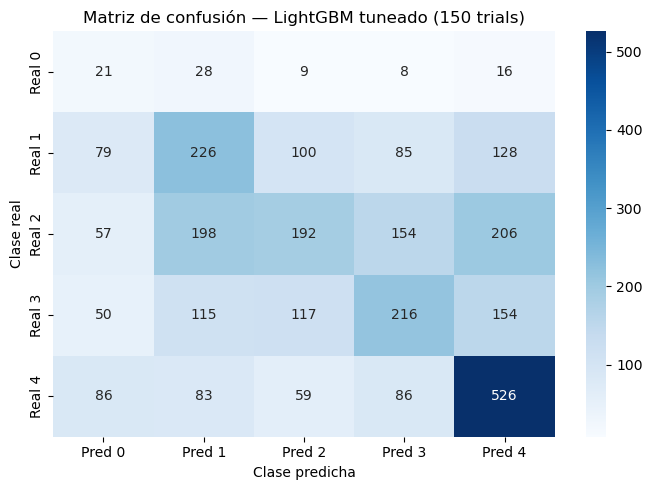

In [10]:
y_pred  = final_model.predict(X_test)
kappa   = cohen_kappa_score(y_test, y_pred, weights='quadratic')
acc     = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print('=== MÃ©tricas sobre test ===')
print(f'  Cohen Kappa (quadratic): {kappa:.4f}')
print(f'  Accuracy:                {acc:.4f}')
print(f'  Balanced Accuracy:       {bal_acc:.4f}')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred {i}' for i in range(5)],
            yticklabels=[f'Real {i}' for i in range(5)])
plt.title('Matriz de confusiÃ³n â€” LightGBM tuneado (150 trials)')
plt.ylabel('Clase real')
plt.xlabel('Clase predicha')
plt.tight_layout()
plt.show()

C:\Users\Hp EliteBook\AppData\Local\Temp\ipykernel_7780\1512721168.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='importance', y='feature', palette='viridis')


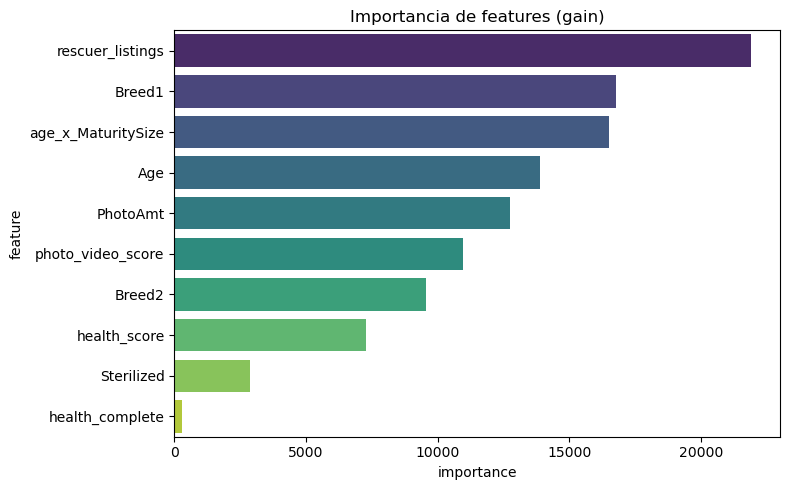

In [11]:
importance = pd.DataFrame({
    'feature': FEATURES_SEL,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='importance', y='feature', palette='viridis')
plt.title('Importancia de features (gain)')
plt.tight_layout()
plt.show()

## Predicciones sobre test

In [14]:
resultado = test[['PetID']].copy()
resultado['AdoptionSpeed_real']     = y_test.values
resultado['AdoptionSpeed_predicho'] = y_pred
resultado.to_csv(os.path.join(BASE_DIR, 'delfina/mica/predicciones_test.csv'), index=False)
print('Predicciones guardadas.')
resultado.head(10)

OSError: Cannot save file into a non-existent directory: 'c:\Users\Hp EliteBook\Documents\GitHub\UA_MDM_Labo2_Grupo10\delfina\delfina\mica'